In [1]:
import pandas as pd
import numpy as np
import glob

In [2]:
files = glob.glob("*.csv")
files

['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
 'Friday-WorkingHours-Morning.pcap_ISCX.csv',
 'Wednesday-workingHours.pcap_ISCX.csv']

In [3]:
dfs = [pd.read_csv(file) for file in files]
df = pd.concat(dfs, ignore_index=True)

In [4]:
df.shape


(1395948, 79)

In [6]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [7]:
df.columns = df.columns.str.strip()

In [8]:
df["Label"].value_counts()

Label
BENIGN              854353
DoS Hulk            231073
PortScan            158930
DDoS                128027
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Bot                   1966
Heartbleed              11
Name: count, dtype: int64

In [9]:
df["Label"] = df["Label"].replace({
    "BENIGN": "Normal",
    "DDoS": "DDoS",
    "PortScan": "Port Scan",
    "Bot": "Botnet",
    "DoS Hulk": "HTTP Flood",
    "DoS GoldenEye": "HTTP Flood",
    "DoS slowloris": "HTTP Flood",
    "DoS Slowhttptest": "HTTP Flood"
})

In [11]:
df = df[df["Label"] != "Heartbleed"]

In [12]:
df["Label"].value_counts()

Label
Normal        854353
HTTP Flood    252661
Port Scan     158930
DDoS          128027
Botnet          1966
Name: count, dtype: int64

In [13]:
# total columns
print("Total Columns:", len(df.columns))

# all column names
print("\nAll Columns:\n")
for i, col in enumerate(df.columns, 1):
    print(i, col)

# feature columns except label
feature_cols = [col for col in df.columns if col != "Label"]

print("\nTotal Input Features:", len(feature_cols))
print("\nTarget Column: Label")

Total Columns: 79

All Columns:

1 Destination Port
2 Flow Duration
3 Total Fwd Packets
4 Total Backward Packets
5 Total Length of Fwd Packets
6 Total Length of Bwd Packets
7 Fwd Packet Length Max
8 Fwd Packet Length Min
9 Fwd Packet Length Mean
10 Fwd Packet Length Std
11 Bwd Packet Length Max
12 Bwd Packet Length Min
13 Bwd Packet Length Mean
14 Bwd Packet Length Std
15 Flow Bytes/s
16 Flow Packets/s
17 Flow IAT Mean
18 Flow IAT Std
19 Flow IAT Max
20 Flow IAT Min
21 Fwd IAT Total
22 Fwd IAT Mean
23 Fwd IAT Std
24 Fwd IAT Max
25 Fwd IAT Min
26 Bwd IAT Total
27 Bwd IAT Mean
28 Bwd IAT Std
29 Bwd IAT Max
30 Bwd IAT Min
31 Fwd PSH Flags
32 Bwd PSH Flags
33 Fwd URG Flags
34 Bwd URG Flags
35 Fwd Header Length
36 Bwd Header Length
37 Fwd Packets/s
38 Bwd Packets/s
39 Min Packet Length
40 Max Packet Length
41 Packet Length Mean
42 Packet Length Std
43 Packet Length Variance
44 FIN Flag Count
45 SYN Flag Count
46 RST Flag Count
47 PSH Flag Count
48 ACK Flag Count
49 URG Flag Count
50 CWE Fla

In [14]:
selected_features = [
    "Destination Port",
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packets/s",
    "Bwd Packets/s",
    "Packet Length Mean",
    "Packet Length Std",
    "Average Packet Size",
    "Min Packet Length",
    "Max Packet Length",
    "SYN Flag Count",
    "RST Flag Count",
    "PSH Flag Count",
    "ACK Flag Count",
    "Down/Up Ratio",
    "Flow IAT Mean",
    "Flow IAT Std",
    "Idle Mean",
    "Active Mean",
    "Subflow Fwd Bytes",
    "Subflow Bwd Bytes"
]

# create new table
X = df[selected_features]

# target column
y = df["Label"]

# final dataframe
final_df = df[selected_features + ["Label"]]

print(final_df.shape)
final_df.head()

(1395937, 27)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Fwd Packets/s,Bwd Packets/s,...,PSH Flag Count,ACK Flag Count,Down/Up Ratio,Flow IAT Mean,Flow IAT Std,Idle Mean,Active Mean,Subflow Fwd Bytes,Subflow Bwd Bytes,Label
0,54865,3,2,0,12,0,4.000000e+06,666666.66670,666666.666700,0.000000,...,0,1,0,3.0,0.0,0.0,0.0,12,0,Normal
1,55054,109,1,1,6,6,1.100917e+05,18348.62385,9174.311927,9174.311927,...,0,1,1,109.0,0.0,0.0,0.0,6,6,Normal
2,55055,52,1,1,6,6,2.307692e+05,38461.53846,19230.769230,19230.769230,...,0,1,1,52.0,0.0,0.0,0.0,6,6,Normal
3,46236,34,1,1,6,6,3.529412e+05,58823.52941,29411.764710,29411.764710,...,0,1,1,34.0,0.0,0.0,0.0,6,6,Normal
4,54863,3,2,0,12,0,4.000000e+06,666666.66670,666666.666700,0.000000,...,0,1,0,3.0,0.0,0.0,0.0,12,0,Normal


In [15]:
final_df.to_csv("selected_features_dataset.csv", index=False)

In [17]:
final_df.shape

(1395937, 27)

In [18]:
final_df.isnull().sum()

Destination Port                  0
Flow Duration                     0
Total Fwd Packets                 0
Total Backward Packets            0
Total Length of Fwd Packets       0
Total Length of Bwd Packets       0
Flow Bytes/s                   1055
Flow Packets/s                    0
Fwd Packets/s                     0
Bwd Packets/s                     0
Packet Length Mean                0
Packet Length Std                 0
Average Packet Size               0
Min Packet Length                 0
Max Packet Length                 0
SYN Flag Count                    0
RST Flag Count                    0
PSH Flag Count                    0
ACK Flag Count                    0
Down/Up Ratio                     0
Flow IAT Mean                     0
Flow IAT Std                      0
Idle Mean                         0
Active Mean                       0
Subflow Fwd Bytes                 0
Subflow Bwd Bytes                 0
Label                             0
dtype: int64

In [19]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1395937 entries, 0 to 1395947
Data columns (total 27 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Destination Port             1395937 non-null  int64  
 1   Flow Duration                1395937 non-null  int64  
 2   Total Fwd Packets            1395937 non-null  int64  
 3   Total Backward Packets       1395937 non-null  int64  
 4   Total Length of Fwd Packets  1395937 non-null  int64  
 5   Total Length of Bwd Packets  1395937 non-null  int64  
 6   Flow Bytes/s                 1394882 non-null  float64
 7   Flow Packets/s               1395937 non-null  float64
 8   Fwd Packets/s                1395937 non-null  float64
 9   Bwd Packets/s                1395937 non-null  float64
 10  Packet Length Mean           1395937 non-null  float64
 11  Packet Length Std            1395937 non-null  float64
 12  Average Packet Size          1395937 non-null  

In [22]:
final_df = df.loc[:, selected_features + ["Label"]].copy()

In [23]:
final_df.loc[:, "Flow Bytes/s"] = final_df["Flow Bytes/s"].fillna(
    final_df["Flow Bytes/s"].median()
)

In [24]:
final_df.isnull().sum()

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Flow Bytes/s                   0
Flow Packets/s                 0
Fwd Packets/s                  0
Bwd Packets/s                  0
Packet Length Mean             0
Packet Length Std              0
Average Packet Size            0
Min Packet Length              0
Max Packet Length              0
SYN Flag Count                 0
RST Flag Count                 0
PSH Flag Count                 0
ACK Flag Count                 0
Down/Up Ratio                  0
Flow IAT Mean                  0
Flow IAT Std                   0
Idle Mean                      0
Active Mean                    0
Subflow Fwd Bytes              0
Subflow Bwd Bytes              0
Label                          0
dtype: int64

In [25]:
final_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Fwd Packets/s,Bwd Packets/s,...,PSH Flag Count,ACK Flag Count,Down/Up Ratio,Flow IAT Mean,Flow IAT Std,Idle Mean,Active Mean,Subflow Fwd Bytes,Subflow Bwd Bytes,Label
0,54865,3,2,0,12,0,4.000000e+06,666666.66670,666666.666700,0.000000,...,0,1,0,3.0,0.0,0.0,0.0,12,0,Normal
1,55054,109,1,1,6,6,1.100917e+05,18348.62385,9174.311927,9174.311927,...,0,1,1,109.0,0.0,0.0,0.0,6,6,Normal
2,55055,52,1,1,6,6,2.307692e+05,38461.53846,19230.769230,19230.769230,...,0,1,1,52.0,0.0,0.0,0.0,6,6,Normal
3,46236,34,1,1,6,6,3.529412e+05,58823.52941,29411.764710,29411.764710,...,0,1,1,34.0,0.0,0.0,0.0,6,6,Normal
4,54863,3,2,0,12,0,4.000000e+06,666666.66670,666666.666700,0.000000,...,0,1,0,3.0,0.0,0.0,0.0,12,0,Normal


In [26]:
X = final_df.drop(columns=["Label"])
y = final_df["Label"]

In [27]:
print(X.shape)
print(y.shape)

(1395937, 26)
(1395937,)


In [36]:
import numpy as np

# Replace inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Fill NaN with median
X = X.fillna(X.median())

In [37]:
print(np.isinf(X.values).sum())
print(X.isnull().sum().sum())

0
0


In [38]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

print(le.classes_)

[0 1 2 3 4]


In [53]:
final_df = final_df.drop_duplicates()

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [55]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

In [56]:
model.fit(X_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
y_pred = model.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.997460492571314


In [59]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=[str(x) for x in le.classes_]
))

              precision    recall  f1-score   support

           0       0.66      0.62      0.64       393
           1       1.00      1.00      1.00     25606
           2       0.99      1.00      1.00     50532
           3       1.00      1.00      1.00    170871
           4       1.00      1.00      1.00     31786

    accuracy                           1.00    279188
   macro avg       0.93      0.92      0.93    279188
weighted avg       1.00      1.00      1.00    279188



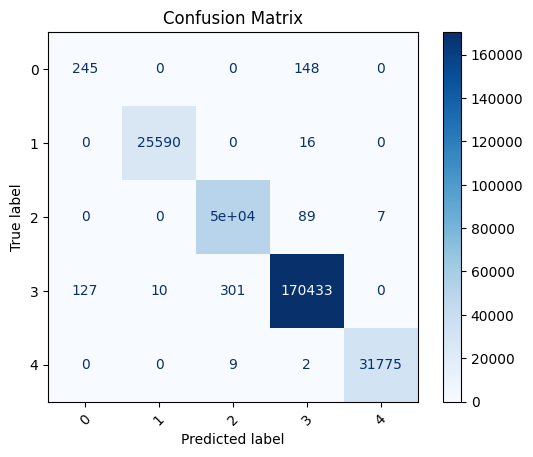

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

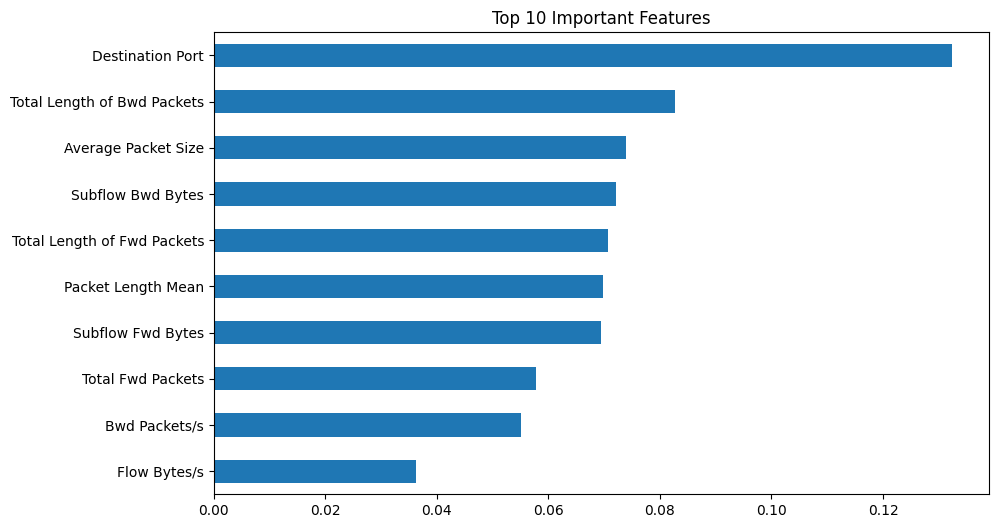

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=True).tail(10).plot(kind="barh", figsize=(10,6))
plt.title("Top 10 Important Features")
plt.show()

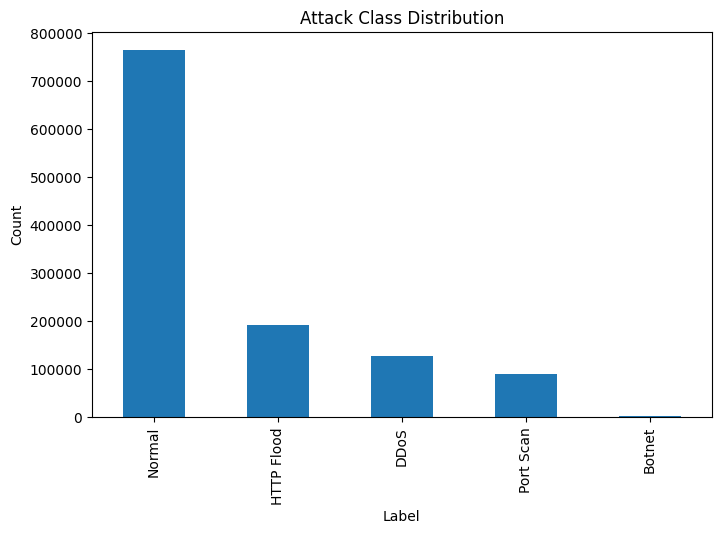

In [62]:
final_df["Label"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Attack Class Distribution")
plt.ylabel("Count")
plt.show()

In [63]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.997460492571314


In [64]:
test_df = X_test.copy()
test_df["Actual_Label"] = le.inverse_transform(y_test)
test_df["Predicted_Label"] = le.inverse_transform(y_pred)

test_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Fwd Packets/s,Bwd Packets/s,...,ACK Flag Count,Down/Up Ratio,Flow IAT Mean,Flow IAT Std,Idle Mean,Active Mean,Subflow Fwd Bytes,Subflow Bwd Bytes,Actual_Label,Predicted_Label
1269018,53,31336,2,2,78,204,8999.234108,127.648711,63.824355,63.824355,...,0,1,1.044533e+04,1.808838e+04,0.0,0.0,78,204,3,3
751163,52763,3,2,0,0,0,0.000000,666666.666700,666666.666700,0.000000,...,1,0,3.000000e+00,0.000000e+00,0.0,0.0,0,0,3,3
441002,17877,43,1,1,0,6,139534.883700,46511.627910,23255.813950,23255.813950,...,0,1,4.300000e+01,0.000000e+00,0.0,0.0,0,6,4,4
6571,53,47148,1,1,57,119,3732.926105,42.419615,21.209807,21.209807,...,0,1,4.714800e+04,0.000000e+00,0.0,0.0,57,119,3,3
910304,80,85766478,10,6,1460,11595,152.215648,0.186553,0.116596,0.069957,...,1,0,5.717765e+06,2.190000e+07,84900000.0,995.0,1460,11595,2,2


In [65]:
test_df.to_csv("test_dataset_predictions.csv", index=False)